In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Notebook 01 – Dataset Exploration

## Objective

The objective of this notebook is to explore the Dryad ECG dataset, understand its structure, assess data quality, and identify the variables that can support the final dissertation methodology.

Rather than assuming a prediction task, this notebook investigates the available ECG, blood pressure (ABPM), continuous glucose monitoring (CGM), respiratory, accelerometer, and summary data to determine which targets are scientifically appropriate.

This notebook forms the foundation for all subsequent preprocessing, feature engineering, modelling, and evaluation.

#cell 2

In [ ]:
# Cell 2 - Import Libraries

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#cell 3

In [ ]:


drive_path = "/content/drive/MyDrive"

print("Drive exists:", os.path.exists(drive_path))

print("\nFolders inside MyDrive:\n")

for folder in os.listdir(drive_path):
    print(folder)

Drive exists: True

Folders inside MyDrive:

Colab Notebooks
QMUL_MSc_Dissertation


## 4. Locate the Dataset

This section verifies that the dissertation dataset is accessible from Google Drive before beginning the exploratory analysis.

#cell 4

In [ ]:
# Project root directory
project_path = "/content/drive/MyDrive/QMUL_MSc_Dissertation"

# Verify the project exists
print(f"Project folder exists: {os.path.exists(project_path)}\n")

# List all files currently available
print("Files currently available:\n")

for item in os.listdir(project_path):
    print(item)

Project folder exists: True

Files currently available:

README.md
Participant_Information.csv
Data_Collection_Notes.csv
Blood_Pressure_Sleep_Info.xlsx
Per_Participant_Sensor_Data.zip
Notebook3_Exports
Notebook4_Waveform_Cache
Notebook4_LSTM_Checkpoints
Notebook4_CNN_Checkpoints
Notebook5_Optimisation_Checkpoints


## 5. Explore the Available Dataset Files

Before analysing the physiological signals, it is important to inspect the metadata files provided with the dataset. These files describe the participants, data collection protocol, and study information, which helps in understanding the structure and scope of the dataset.

In [ ]:
# Cell 5 - Load Metadata Files

participant_info = pd.read_csv(
    os.path.join(project_path, "Participant_Information.csv")
)

data_notes = pd.read_csv(
    os.path.join(project_path, "Data_Collection_Notes.csv")
)

blood_pressure_info = pd.read_excel(
    os.path.join(project_path, "Blood_Pressure_Sleep_Info.xlsx")
)

print("All metadata files loaded successfully.")

All metadata files loaded successfully.


In [ ]:
# Cell 6 - Display Dataset Dimensions

print("Participant Information:", participant_info.shape)
print("Data Collection Notes:", data_notes.shape)
print("Blood Pressure & Sleep Info:", blood_pressure_info.shape)

Participant Information: (30, 6)
Data Collection Notes: (30, 7)
Blood Pressure & Sleep Info: (1623, 9)


In [ ]:
# Cell 7 - Preview the Metadata

print("Participant Information")
display(participant_info.head())

print("\nData Collection Notes")
display(data_notes.head())

print("\nBlood Pressure & Sleep Information")
display(blood_pressure_info.head())

Participant Information


,ID,Sex,Age,BMI,Caffeine (number of cups per day),Alcohol (number of units per day)
0,1,1,2,22.9,2,2.0
1,2,0,3,34.0,7,3.0
2,3,1,6,19.6,0,0.0
3,4,0,1,19.8,2,0.0
4,5,0,2,25.9,2,0.0



Data Collection Notes


,ID,CGM? Yes/No,Issue reported/known?,Zephyr unit,BP monitor,BP cuff,ECG setup
0,1,Y,N,BHT052124,1 (227-014914),Regular,electrodes
1,2,N,N,BHT052124,1 (227-014914),Regular,electrodes
2,3,N,N,BHT052124,1 (227-014914),Regular,electrodes
3,4,N,N,BHT056204,3 (227-020929),Regular,electrodes
4,5,N,N,BHT052162,2 (227-020930),Regular,strap



Blood Pressure & Sleep Information


,ID,Day_Date,Time,Systolic,Diastolic,MAP,PP,HR,Wake_Sleep
0,1,06/06/2022,11:17:00,0,0,0,0,0,1
1,1,06/06/2022,11:17:00,125,75,92,50,72,1
2,1,06/06/2022,11:19:00,125,74,90,51,73,1
3,1,06/06/2022,11:21:00,113,72,85,41,73,1
4,1,06/06/2022,11:29:00,109,69,80,40,77,1


## 5.1 Metadata Quality Assessment

This section evaluates the completeness and structure of the metadata by checking column names, data types, and missing values. These checks help identify potential data quality issues before analysing the physiological signals.

In [ ]:
# Cell 8 - Inspect Columns and Data Types

datasets = {
    "Participant Information": participant_info,
    "Data Collection Notes": data_notes,
    "Blood Pressure & Sleep Info": blood_pressure_info
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\n")

Participant Information

Columns:
['ID', 'Sex', 'Age', 'BMI', 'Caffeine (number of cups per day)', 'Alcohol (number of units per day)']

Data Types:
ID                                     int64
Sex                                    int64
Age                                    int64
BMI                                  float64
Caffeine (number of cups per day)      int64
Alcohol (number of units per day)    float64
dtype: object


Data Collection Notes

Columns:
['ID', 'CGM? Yes/No', 'Issue reported/known?', 'Zephyr unit', 'BP monitor', 'BP cuff', 'ECG setup']

Data Types:
ID                        int64
CGM? Yes/No              object
Issue reported/known?    object
Zephyr unit              object
BP monitor               object
BP cuff                  object
ECG setup                object
dtype: object


Blood Pressure & Sleep Info

Columns:
['ID', 'Day_Date', 'Time', 'Systolic', 'Diastolic', 'MAP', 'PP', 'HR', 'Wake_Sleep']

Data Types:
ID             int64
Day_Date      object
Ti

In [ ]:
# Cell 9 - Check Missing Values

for name, df in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    missing = df.isnull().sum()

    display(missing)

    print()

Participant Information


,0
ID,0
Sex,0
Age,0
BMI,0
Caffeine (number of cups per day),0
Alcohol (number of units per day),0



Data Collection Notes


,0
ID,0
CGM? Yes/No,0
Issue reported/known?,0
Zephyr unit,0
BP monitor,0
BP cuff,0
ECG setup,0



Blood Pressure & Sleep Info


,0
ID,0
Day_Date,0
Time,0
Systolic,0
Diastolic,0
MAP,0
PP,0
HR,0
Wake_Sleep,0


In [ ]:
# Cell 10 - Blood Pressure Readings Per Participant

bp_counts = blood_pressure_info["ID"].value_counts().sort_index()

display(bp_counts)

print("\nSummary Statistics")

display(bp_counts.describe())

,count
ID,
1,48
2,54
3,49
4,49
5,50
6,50
7,55
8,53
9,57



Summary Statistics


,count
count,30.000000
mean,54.100000
std,7.800752
min,31.000000
25%,50.000000
50%,53.500000
75%,57.000000
max,78.000000


## 5.2 Blood Pressure Data Quality

Although the dataset contains no missing (NaN) values, physiological datasets may contain placeholder or invalid measurements. Therefore, additional quality checks are performed to identify impossible blood pressure values that could affect subsequent analyses.

In [ ]:
# Cell 11 - Blood Pressure Data Quality Check

print("=" * 70)
print("Blood Pressure Data Quality Check")
print("=" * 70)

# Check for impossible blood pressure values
invalid_bp = blood_pressure_info[
    (blood_pressure_info["Systolic"] <= 0) |
    (blood_pressure_info["Diastolic"] <= 0) |
    (blood_pressure_info["MAP"] <= 0) |
    (blood_pressure_info["HR"] <= 0)
]

print(f"\nNumber of potentially invalid BP records: {len(invalid_bp)}")

if len(invalid_bp) > 0:
    display(invalid_bp.head(10))
else:
    print("No invalid blood pressure records found.")

Blood Pressure Data Quality Check

Number of potentially invalid BP records: 533


,ID,Day_Date,Time,Systolic,Diastolic,MAP,PP,HR,Wake_Sleep
0,1,06/06/2022,11:17:00,0,0,0,0,0,1
5,1,06/06/2022,11:32:00,0,0,0,0,0,1
13,1,06/06/2022,15:09:00,0,0,0,0,0,1
17,1,06/06/2022,16:39:00,0,0,0,0,0,1
18,1,06/06/2022,16:42:00,0,0,0,0,0,1
28,1,06/06/2022,21:19:00,0,0,0,0,0,1
31,1,07/06/2022,00:09:00,0,0,0,0,0,0
38,1,07/06/2022,06:09:00,0,0,0,0,0,1
51,2,21/06/2022,08:41:00,0,0,0,0,0,1
61,2,21/06/2022,12:47:00,0,0,0,0,0,1


## 8. Review the Dataset Documentation

Before loading the physiological signals, the official dataset documentation is reviewed to understand the organisation of the files, sensor modalities, and participant data structure.

In [ ]:
# Cell 12 - Read the README file

readme_path = os.path.join(project_path, "README.md")

with open(readme_path, "r", encoding="utf-8") as file:
    readme = file.read()

print(readme)

# Dataset README: Multimodal Physiological Sensor Data

24-hour physiological monitoring; electrocardiogram, interstitial glucose, ambulatory blood pressure
Dataset DOI: [https://doi.org/10.5061/dryad.qjq2bvqpk](https://doi.org/10.5061/dryad.qjq2bvqpk)

This dataset contains multimodal physiological recordings from 30 study participants, collected using wearable sensors and monitoring devices. It includes raw and segmented data from ECG and activity monitors, continuous glucose monitors (CGM), and ambulatory blood pressure monitors (ABPM), along with device setup notes and sleep annotations.

---

## File Overview

### 1. `Per_Participant_Sensor_Data.zip`

#### Folder Structure

* One folder per participant, named using a three-digit ID (e.g., `001`, `002`, ..., `030`).
* Each participant folder may contain:
  * `ID_Zephyr/` – Zephyr wearable ECG and activity monitor data
  * `ID_glucose.csv` – CGM data (only for participants assigned a CGM)
  * `ID_ABPM` – ABPM data

#### a. Zephyr Su

### Note on Participant Variables

The dataset documentation does not specify the encoding used for the `Age` and `Sex` variables in `Participant_Information.csv`. Therefore, these variables will be treated as encoded participant metadata and will not be interpreted until their coding scheme is confirmed from the original study or supplementary documentation.

## 9. Participant-Level Dataset Verification

Before performing detailed ECG analysis, the participant folders are checked systematically to verify the organisation of the dataset and identify the availability of ECG recordings across the complete participant set.

Participant 030 is then used as a representative recording for detailed ECG inspection and initial validation of the analysis workflow. This allows the processing approach to be examined on a manageable example before being applied systematically to the remaining participants in subsequent analysis.

In [ ]:
# Cell 13 - Verify Participant Dataset Structure

participant_root = os.path.join(
    project_path,
    "Per_Participant_Sensor_Data"
)

print("=" * 70)
print("Participant Dataset Structure")
print("=" * 70)

print("\nParticipant data directory:")
print(participant_root)

print("\nDirectory exists:", os.path.exists(participant_root))

# Identify participant folders
participant_folders = sorted(
    [
        folder
        for folder in os.listdir(participant_root)
        if os.path.isdir(os.path.join(participant_root, folder))
    ]
)

print("\nNumber of participant folders:", len(participant_folders))

print("\nParticipant IDs:")
print(participant_folders)

Participant Dataset Structure

Participant data directory:
/content/drive/MyDrive/QMUL_MSc_Dissertation/Per_Participant_Sensor_Data

Directory exists: True

Number of participant folders: 30

Participant IDs:
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030']


In [ ]:
# Cell 14 - Participant File Availability

import glob

# File types we want to check
file_patterns = {
    "Accel": "*Accel*.csv",
    "BB": "*BB*.csv",
    "Breathing": "*Breathing*.csv",
    "ECG": "*ECG*.csv",
    "Event_Data": "*Event*.csv",
    "RR": "*RR*.csv",
    "Summary": "*Summary*.csv"
}

participant_file_summary = []

for participant_id in participant_folders:

    participant_path_check = os.path.join(
        participant_root,
        participant_id
    )

    row = {
        "Participant": participant_id
    }

    # Search recursively inside each participant folder
    for file_type, pattern in file_patterns.items():

        matching_files = glob.glob(
            os.path.join(
                participant_path_check,
                "**",
                pattern
            ),
            recursive=True
        )

        row[file_type] = len(matching_files)

    participant_file_summary.append(row)


# Convert results to DataFrame
participant_file_summary = pd.DataFrame(
    participant_file_summary
)

# Display complete table
display(participant_file_summary)

,Participant,Accel,BB,Breathing,ECG,Event_Data,RR,Summary
0,001,3,3,3,3,3,3,3
1,002,3,3,3,3,3,3,3
2,003,4,4,4,4,4,4,4
3,004,3,3,3,3,3,3,3
4,005,4,4,4,4,5,4,4
5,006,3,3,3,3,3,3,3
6,007,3,3,3,3,3,3,3
7,008,4,4,4,4,4,4,4
8,009,2,2,2,2,2,2,2
9,010,1,1,1,1,1,1,1


In [ ]:
# Cell 15 - ECG Availability Across All Participants

ecg_availability = []

for participant_id in participant_folders:

    participant_path_check = os.path.join(
        participant_root,
        participant_id
    )

    # Search recursively for ECG files
    ecg_files = glob.glob(
        os.path.join(
            participant_path_check,
            "**",
            "*ECG*.csv"
        ),
        recursive=True
    )

    ecg_availability.append({
        "Participant": participant_id,
        "ECG_File_Count": len(ecg_files),
        "ECG_Available": len(ecg_files) > 0
    })


# Convert to DataFrame
ecg_availability = pd.DataFrame(
    ecg_availability
)

# Display participant-level ECG availability
display(ecg_availability)

# Overall summary
print("\n" + "=" * 70)
print("ECG Availability Summary")
print("=" * 70)

print(
    "\nTotal participants:",
    len(participant_folders)
)

print(
    "Participants with ECG data:",
    int(ecg_availability["ECG_Available"].sum())
)

print(
    "Participants without ECG data:",
    int((~ecg_availability["ECG_Available"]).sum())
)

,Participant,ECG_File_Count,ECG_Available
0,001,3,True
1,002,3,True
2,003,4,True
3,004,3,True
4,005,4,True
5,006,3,True
6,007,3,True
7,008,4,True
8,009,2,True
9,010,1,True



ECG Availability Summary

Total participants: 30
Participants with ECG data: 30
Participants without ECG data: 0


## 10. Detailed ECG Inspection of Participant 030

Following the participant-level dataset verification and ECG availability assessment, participant 030 is selected as a representative recording for detailed ECG inspection. This step is used to examine the raw ECG structure, data quality, sampling characteristics, and waveform before the processing workflow is extended to the remaining participants.

In [ ]:
# Cell 16 - Identify ECG Files for Participant 030

import glob

# Select the representative participant
participant_id = "030"

participant_path = os.path.join(
    participant_root,
    participant_id
)

print("=" * 70)
print("Representative Participant ECG Files")
print("=" * 70)

print("\nSelected participant:", participant_id)

print(
    "Participant folder exists:",
    os.path.exists(participant_path)
)

# Search recursively for all ECG CSV files
ecg_files = glob.glob(
    os.path.join(
        participant_path,
        "**",
        "*ECG*.csv"
    ),
    recursive=True
)

print("\nNumber of ECG files found:", len(ecg_files))

print("\nECG files found:")

for i, file in enumerate(ecg_files, start=1):
    file_size_mb = os.path.getsize(file) / (1024 ** 2)

    print(
        f"{i}. {os.path.basename(file)} "
        f"({file_size_mb:.2f} MB)"
    )

Representative Participant ECG Files

Selected participant: 030
Participant folder exists: True

Number of ECG files found: 1

ECG files found:
1. 2023_09_05__12_13_37_ECG.csv (627.21 MB)


In [ ]:
# Cell 17 - Load Raw ECG Signal for Participant 030

# Select the ECG file identified in Cell 16
ecg_file = ecg_files[0]

print("=" * 70)
print("Loading Raw ECG Signal - Participant 030")
print("=" * 70)

print("\nSelected ECG file:")
print(os.path.basename(ecg_file))

print("\nLoading ECG data...")

ecg = pd.read_csv(ecg_file)

print("\nECG loaded successfully.")

print("\nShape:")
print(ecg.shape)

print("\nColumns:")
print(ecg.columns.tolist())

Loading Raw ECG Signal - Participant 030

Selected ECG file:
2023_09_05__12_13_37_ECG.csv

Loading ECG data...

ECG loaded successfully.

Shape:
(21924250, 2)

Columns:
['Time', 'EcgWaveform']


In [ ]:
# Cell 18 - Inspect ECG Dataset Structure

print("=" * 70)
print("ECG Dataset Structure - Participant 030")
print("=" * 70)

print("\nShape:")
print(ecg.shape)

print("\nColumn Names:")
print(ecg.columns.tolist())

print("\nData Types:")
print(ecg.dtypes)

print("\nFirst 5 rows:")
display(ecg.head())

ECG Dataset Structure - Participant 030

Shape:
(21924250, 2)

Column Names:
['Time', 'EcgWaveform']

Data Types:
Time           object
EcgWaveform     int64
dtype: object

First 5 rows:


,Time,EcgWaveform
0,05/09/2023 12:13:37.427,179
1,05/09/2023 12:13:37.431,179
2,05/09/2023 12:13:37.435,179
3,05/09/2023 12:13:37.439,179
4,05/09/2023 12:13:37.443,179


In [ ]:
# Cell 19 - Check Missing Values in ECG Data

print("=" * 70)
print("Missing Values in ECG Dataset - Participant 030")
print("=" * 70)

missing_values = ecg.isnull().sum()

display(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())

Missing Values in ECG Dataset - Participant 030


,0
Time,0
EcgWaveform,0



Total missing values:
0


In [ ]:
# Cell 20 - Estimate ECG Sampling Frequency

# Convert Time column to datetime
ecg["Time"] = pd.to_datetime(
    ecg["Time"],
    format="%d/%m/%Y %H:%M:%S.%f"
)

# Calculate time difference between consecutive samples
time_diff = ecg["Time"].diff().dt.total_seconds()

# Estimate the typical sampling interval
sampling_interval = time_diff.median()

# Calculate sampling frequency
sampling_frequency = 1 / sampling_interval

print("=" * 70)
print("ECG Sampling Frequency - Participant 030")
print("=" * 70)

print(
    f"\nMedian sampling interval: "
    f"{sampling_interval:.6f} seconds"
)

print(
    f"Estimated sampling frequency: "
    f"{sampling_frequency:.2f} Hz"
)

ECG Sampling Frequency - Participant 030

Median sampling interval: 0.004000 seconds
Estimated sampling frequency: 250.00 Hz


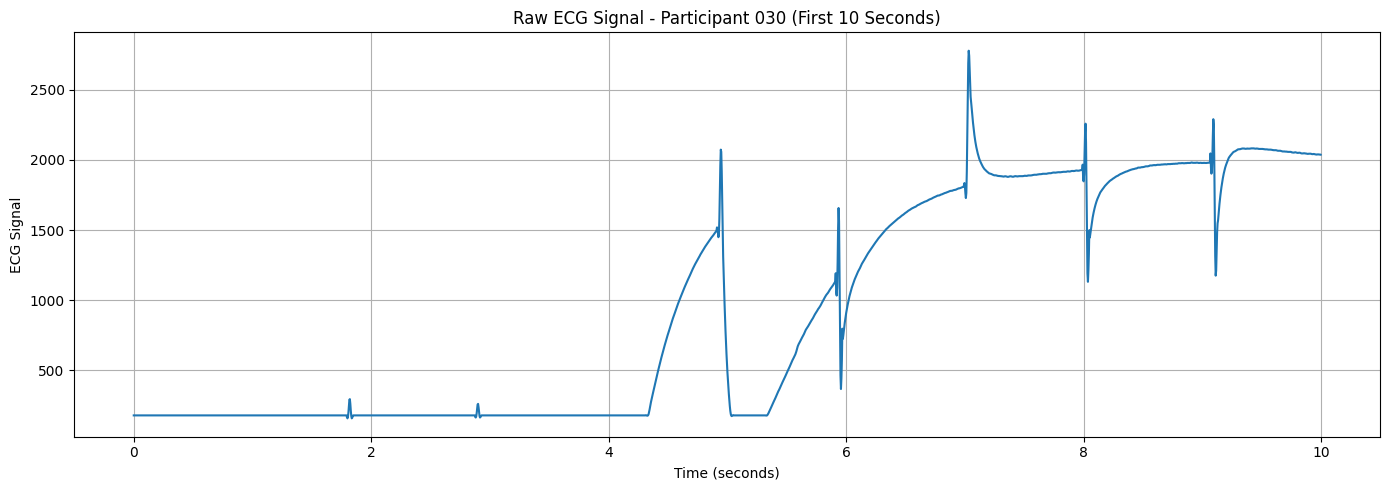

In [ ]:
# Cell 21 - Visualise the Raw ECG Signal

# Display the first 10 seconds of the ECG recording
samples_to_plot = int(sampling_frequency * 10)

time_seconds = (
    np.arange(samples_to_plot)
    / sampling_frequency
)

ecg_values = ecg["EcgWaveform"].iloc[:samples_to_plot]

plt.figure(figsize=(14, 5))

plt.plot(
    time_seconds,
    ecg_values
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Signal")

plt.title(
    "Raw ECG Signal - Participant 030 "
    "(First 10 Seconds)"
)

plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Dataset-Wide ECG File Summary

Following the detailed inspection of participant 030, the ECG recordings across all participants are summarised at file level. This provides an overview of the number of ECG files available for each participant without loading all large raw ECG recordings into memory simultaneously.

In [ ]:
# Cell 22 - Dataset-Wide ECG File Summary

ecg_file_summary = []

for participant_id in participant_folders:

    participant_path_check = os.path.join(
        participant_root,
        participant_id
    )

    # Find all ECG files for this participant
    ecg_files_participant = glob.glob(
        os.path.join(
            participant_path_check,
            "**",
            "*ECG*.csv"
        ),
        recursive=True
    )

    # Record each ECG file individually
    for ecg_path in ecg_files_participant:

        file_size_mb = (
            os.path.getsize(ecg_path) / (1024 ** 2)
        )

        ecg_file_summary.append({
            "Participant": participant_id,
            "ECG_File": os.path.basename(ecg_path),
            "File_Size_MB": round(file_size_mb, 2)
        })


# Convert to DataFrame
ecg_file_summary = pd.DataFrame(
    ecg_file_summary
)

# Display the complete summary
display(ecg_file_summary)

print("\n" + "=" * 70)
print("Dataset-Wide ECG Summary")
print("=" * 70)

print(
    "\nTotal ECG files:",
    len(ecg_file_summary)
)

print(
    "Participants represented:",
    ecg_file_summary["Participant"].nunique()
)

print(
    "Total ECG data size:",
    f"{ecg_file_summary['File_Size_MB'].sum():,.2f} MB"
)

,Participant,ECG_File,File_Size_MB
0,001,2022_06_06__10_28_26_ECG.csv,132.93
1,001,2022_06_06__15_38_43_ECG.csv,478.08
2,001,2022_06_07__10_42_46_ECG.csv,41.47
3,002,2022_06_21__08_03_26_ECG.csv,17.08
4,002,2022_06_21__08_43_49_ECG.csv,81.01
5,002,2022_06_21__11_53_12_ECG.csv,578.18
6,003,2022_08_01__09_38_43_ECG.csv,1.82
7,003,2022_08_01__09_59_53_ECG.csv,2.97
8,003,2022_08_01__10_06_54_ECG.csv,0.04
9,003,2022_08_01__10_08_04_ECG.csv,640.02



Dataset-Wide ECG Summary

Total ECG files: 58
Participants represented: 30
Total ECG data size: 19,058.33 MB


## 13. Notebook 1 Findings

The dataset was first examined at the participant level to verify the available data structure and ECG recordings across the study cohort. Participant 030 was then selected as a representative recording for detailed ECG inspection, including signal structure, missing-value assessment, sampling-frequency estimation, and visualisation of the raw waveform.

The participant-level checks confirmed the availability of ECG recordings across the dataset, while the detailed analysis of participant 030 provided an initial validation of the ECG inspection workflow. The subsequent notebook will extend the validated processing workflow systematically to the eligible participant recordings.

In [ ]:
# Cell 23 - Notebook 1 Summary

print("=" * 70)
print("Notebook 1 - Dataset Exploration Summary")
print("=" * 70)

print(
    f"\nTotal participant folders identified: "
    f"{len(participant_folders)}"
)

print(
    "Participants with ECG data: "
    f"{int(ecg_availability['ECG_Available'].sum())}"
)

print(
    "Participants without ECG data: "
    f"{int((~ecg_availability['ECG_Available']).sum())}"
)

print(
    "\nTotal ECG files identified: "
    f"{len(ecg_file_summary)}"
)

print(
    "Participants represented in ECG file summary: "
    f"{ecg_file_summary['Participant'].nunique()}"
)

print(
    "\nRepresentative participant analysed in detail: 030"
)

print(
    f"Participant 030 ECG samples: "
    f"{len(ecg):,}"
)

print(
    f"Participant 030 sampling frequency: "
    f"{sampling_frequency:.2f} Hz"
)

print(
    f"Participant 030 missing values: "
    f"{int(ecg.isnull().sum().sum())}"
)

print("\nNotebook 1 dataset exploration completed.")

Notebook 1 - Dataset Exploration Summary

Total participant folders identified: 30
Participants with ECG data: 30
Participants without ECG data: 0

Total ECG files identified: 58
Participants represented in ECG file summary: 30

Representative participant analysed in detail: 030
Participant 030 ECG samples: 21,924,250
Participant 030 sampling frequency: 250.00 Hz
Participant 030 missing values: 0

Notebook 1 dataset exploration completed.
